In [1]:
#Import important libraries 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [2]:
# load data
df = pd.read_csv("Airline_Delay_Cause.csv")
df

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2025,1,G4,Allegiant Air,ELM,"Elmira/Corning, NY: Elmira/Corning Regional",30.0,0.0,0.00,0.00,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025,1,G4,Allegiant Air,ELP,"El Paso, TX: El Paso International",2.0,0.0,0.00,0.00,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025,1,G4,Allegiant Air,EUG,"Eugene, OR: Mahlon Sweet Field",28.0,8.0,3.74,0.00,...,0.0,2.66,2.0,0.0,409.0,236.0,0.0,70.0,0.0,103.0
3,2025,1,G4,Allegiant Air,EVV,"Evansville, IN: Evansville Regional",18.0,1.0,0.00,1.00,...,0.0,0.00,0.0,0.0,1075.0,0.0,1075.0,0.0,0.0,0.0
4,2025,1,G4,Allegiant Air,EWR,"Newark, NJ: Newark Liberty International",31.0,5.0,2.17,0.00,...,0.0,0.00,1.0,0.0,446.0,336.0,0.0,110.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
398228,2003,6,DL,Delta Air Lines Inc.,SEA,"Seattle, WA: Seattle/Tacoma International",480.0,84.0,25.69,3.09,...,0.0,21.26,0.0,0.0,3744.0,978.0,164.0,1023.0,0.0,1579.0
398229,2003,6,DL,Delta Air Lines Inc.,SFO,"San Francisco, CA: San Francisco International",505.0,111.0,21.78,2.24,...,0.0,13.17,3.0,0.0,4284.0,1376.0,138.0,2132.0,0.0,638.0
398230,2003,6,DL,Delta Air Lines Inc.,SJC,"San Jose, CA: Norman Y. Mineta San Jose Intern...",146.0,36.0,6.99,0.00,...,0.0,2.15,0.0,0.0,896.0,205.0,0.0,607.0,0.0,84.0
398231,2003,6,DL,Delta Air Lines Inc.,SJU,"San Juan, PR: Luis Munoz Marin International",95.0,13.0,3.66,0.00,...,0.0,1.42,0.0,0.0,367.0,120.0,0.0,210.0,0.0,37.0


In [3]:
# Top five columns 
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2025,1,G4,Allegiant Air,ELM,"Elmira/Corning, NY: Elmira/Corning Regional",30.0,0.0,0.00,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025,1,G4,Allegiant Air,ELP,"El Paso, TX: El Paso International",2.0,0.0,0.00,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025,1,G4,Allegiant Air,EUG,"Eugene, OR: Mahlon Sweet Field",28.0,8.0,3.74,0.0,...,0.0,2.66,2.0,0.0,409.0,236.0,0.0,70.0,0.0,103.0
3,2025,1,G4,Allegiant Air,EVV,"Evansville, IN: Evansville Regional",18.0,1.0,0.00,1.0,...,0.0,0.00,0.0,0.0,1075.0,0.0,1075.0,0.0,0.0,0.0
4,2025,1,G4,Allegiant Air,EWR,"Newark, NJ: Newark Liberty International",31.0,5.0,2.17,0.0,...,0.0,0.00,1.0,0.0,446.0,336.0,0.0,110.0,0.0,0.0


In [4]:
# Last five columns 
df.tail()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
398228,2003,6,DL,Delta Air Lines Inc.,SEA,"Seattle, WA: Seattle/Tacoma International",480.0,84.0,25.69,3.09,...,0.0,21.26,0.0,0.0,3744.0,978.0,164.0,1023.0,0.0,1579.0
398229,2003,6,DL,Delta Air Lines Inc.,SFO,"San Francisco, CA: San Francisco International",505.0,111.0,21.78,2.24,...,0.0,13.17,3.0,0.0,4284.0,1376.0,138.0,2132.0,0.0,638.0
398230,2003,6,DL,Delta Air Lines Inc.,SJC,"San Jose, CA: Norman Y. Mineta San Jose Intern...",146.0,36.0,6.99,0.00,...,0.0,2.15,0.0,0.0,896.0,205.0,0.0,607.0,0.0,84.0
398231,2003,6,DL,Delta Air Lines Inc.,SJU,"San Juan, PR: Luis Munoz Marin International",95.0,13.0,3.66,0.00,...,0.0,1.42,0.0,0.0,367.0,120.0,0.0,210.0,0.0,37.0
398232,2003,6,DL,Delta Air Lines Inc.,SLC,"Salt Lake City, UT: Salt Lake City International",3466.0,454.0,121.15,7.61,...,1.0,102.33,9.0,0.0,16853.0,5384.0,306.0,5686.0,28.0,5449.0


In [5]:
# Count of total number of Rows and Columns 
df.shape

(398233, 21)

In [6]:
# Structure of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398233 entries, 0 to 398232
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 398233 non-null  int64  
 1   month                398233 non-null  int64  
 2   carrier              398233 non-null  object 
 3   carrier_name         398233 non-null  object 
 4   airport              398233 non-null  object 
 5   airport_name         398233 non-null  object 
 6   arr_flights          397576 non-null  float64
 7   arr_del15            397283 non-null  float64
 8   carrier_ct           397576 non-null  float64
 9   weather_ct           397576 non-null  float64
 10  nas_ct               397576 non-null  float64
 11  security_ct          397576 non-null  float64
 12  late_aircraft_ct     397576 non-null  float64
 13  arr_cancelled        397576 non-null  float64
 14  arr_diverted         397576 non-null  float64
 15  arr_delay        

In [7]:
# Statistic summary of dataset
df.describe()

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,398233.000000,398233.000000,397576.000000,397283.000000,397576.000000,397576.000000,397576.000000,397576.000000,397576.000000,397576.000000,397576.000000,397576.000000,397576.000000,397576.000000,397576.000000,397576.000000,397576.000000
mean,2014.421344,6.524078,361.663536,69.593947,20.540331,2.508231,22.209529,0.172630,24.111972,6.789323,0.834168,4167.479403,1309.317177,223.331064,1026.011882,7.144337,1601.667661
std,6.474505,3.463111,993.947394,193.608821,48.314208,9.570840,79.473052,0.826248,74.414722,35.086108,3.792889,12755.983464,3824.984307,883.700515,4335.789252,39.129575,5154.585282
min,2003.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-19.000000,0.000000,0.000000
25%,2009.000000,4.000000,56.000000,8.000000,2.790000,0.000000,1.400000,0.000000,1.510000,0.000000,0.000000,405.000000,134.000000,0.000000,49.000000,0.000000,75.000000
50%,2015.000000,7.000000,113.000000,21.000000,7.510000,0.510000,4.910000,0.000000,5.490000,1.000000,0.000000,1140.000000,410.000000,22.000000,183.000000,0.000000,341.000000
75%,2020.000000,10.000000,255.000000,52.000000,18.650000,2.000000,13.990000,0.000000,16.150000,4.000000,1.000000,2974.000000,1075.000000,155.000000,555.000000,0.000000,1089.000000
max,2025.000000,12.000000,21977.000000,6377.000000,1886.580000,717.940000,4091.270000,80.560000,2588.130000,4951.000000,256.000000,648300.000000,321792.000000,64550.000000,238440.000000,3760.000000,279153.000000


In [8]:
# Column names 
df.columns 

Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay'],
      dtype='object')

In [9]:
# Check null values 
df.isnull().sum()

year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            657
arr_del15              950
carrier_ct             657
weather_ct             657
nas_ct                 657
security_ct            657
late_aircraft_ct       657
arr_cancelled          657
arr_diverted           657
arr_delay              657
carrier_delay          657
weather_delay          657
nas_delay              657
security_delay         657
late_aircraft_delay    657
dtype: int64

In [11]:
# Replace null values with 0
df = df.fillna(0)
print(df.isnull().sum())

year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64


In [12]:
# Check duplicates 
df.duplicated().sum()

np.int64(0)

In [14]:
# calculate which cause contributes the most to total minutes
causes = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
total_minutes = df[causes].sum().sort_values(ascending=False)

print(total_minutes)

late_aircraft_delay    636784622.0
carrier_delay          520553086.0
nas_delay              407917700.0
weather_delay           88791071.0
security_delay           2840417.0
dtype: float64


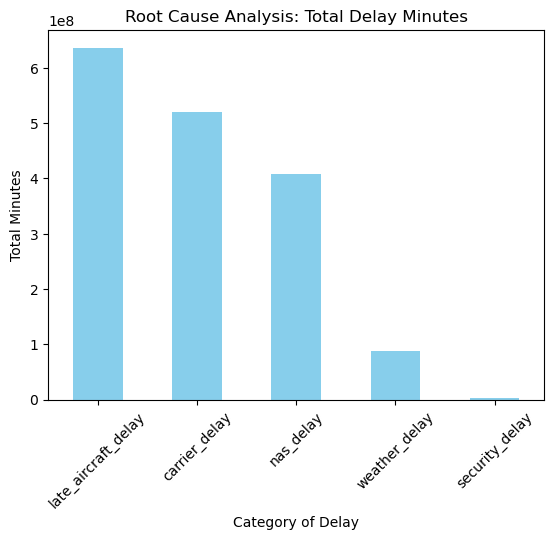

In [17]:
# Root cause analysis 
total_minutes.plot(kind='bar', color='skyblue')
plt.title('Root Cause Analysis: Total Delay Minutes')
plt.ylabel('Total Minutes')
plt.xlabel('Category of Delay')
plt.xticks(rotation=45) # This tilts the text so it's easy to read
plt.show()

In [20]:
print("Root Cause Analysis (Correlation)")
correlation = df[causes + ['arr_delay']].corr()['arr_delay'].sort_values(ascending=False)
print(correlation)

Root Cause Analysis (Correlation)
arr_delay              1.000000
late_aircraft_delay    0.944772
carrier_delay          0.914178
nas_delay              0.861196
weather_delay          0.723889
security_delay         0.405963
Name: arr_delay, dtype: float64


In [22]:
# DELAY PREDICTION MODEL
df = df.dropna(subset=['arr_flights', 'carrier_ct', 'arr_delay'])

# Define X and y
X = df[['arr_flights', 'carrier_ct']]
y = df['arr_delay']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Create and Train the model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
error = mean_absolute_error(y_test, y_pred)

print(f"Model trained successfully!")
print(f"Average Prediction Error: {error:.2f} minutes")

Model trained successfully!
Average Prediction Error: 1645.46 minutes


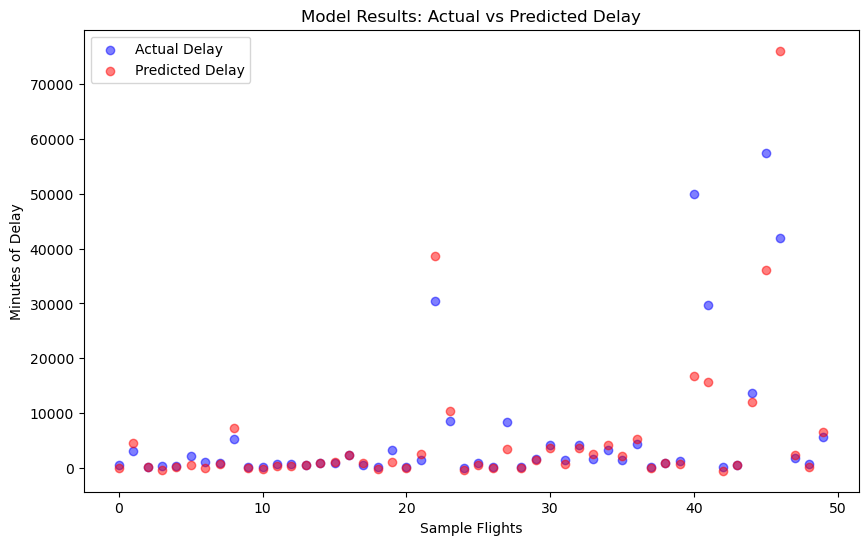

In [23]:
# Actual vs Prediction Delay
plt.figure(figsize=(10,6))
plt.scatter(range(50), y_test[:50], color='blue', label='Actual Delay', alpha=0.5)
plt.scatter(range(50), y_pred[:50], color='red', label='Predicted Delay', alpha=0.5)
plt.title('Model Results: Actual vs Predicted Delay')
plt.xlabel('Sample Flights')
plt.ylabel('Minutes of Delay')
plt.legend()
plt.show()